In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 读取并清洗数据
def read_and_clean_data(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()

    # 提取数据部分
    start_data = False
    data_records = []

    for line in lines:
        if 'isotherm_data' in line:
            start_data = True
        elif start_data and 'pressure' in line:
            pressure = line.split(',')[1].strip().strip('"')
        elif start_data and 'adsorption' in line:
            adsorption = line.split(',')[1].strip().strip('"')
            data_records.append([pressure, adsorption])

    # 转换为DataFrame
    df = pd.DataFrame(data_records, columns=['Pressure (bar)', 'Adsorption (mmol/g)'])
    df['Pressure (bar)'] = pd.to_numeric(df['Pressure (bar)'], errors='coerce')
    df['Adsorption (mmol/g)'] = pd.to_numeric(df['Adsorption (mmol/g)'], errors='coerce')
    return df.dropna()

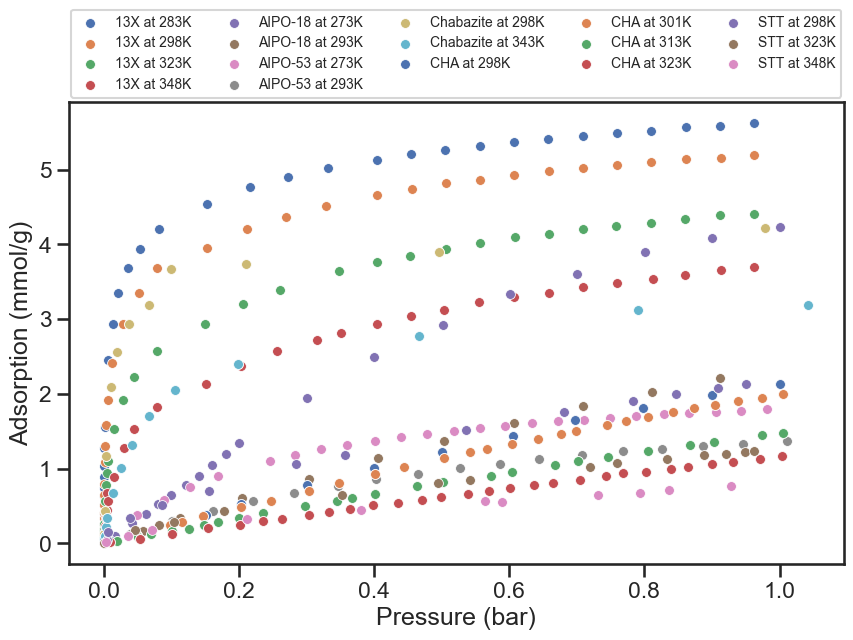

In [10]:
import seaborn as sns

sns.set(style="ticks")
sns.set_context('talk')

# 整合多个数据文件
plt.figure(figsize=(10, 6))

# Dictionary containing all file paths and labels for different zeolites
zeolite_files = {
    'fau': {
        'label': '13X',
        'files': {
            '283K': '../1/fau-co2-283-1.csv',
            '298K': '../1/fau-co2-298-1.csv',
            '323K': '../1/fau-co2-323-1.csv',
            '348K': '../1/fau-co2-348-1.csv'
        }
    },
    'aei': {
        'label': 'AIPO-18',
        'files': {
            '273K': '../1/aei-co2-273-2.csv',
            '293K': '../1/aei-co2-293-2.csv'
        }
    },
    'aen': {
        'label': 'AIPO-53',
        'files': {
            '273K': '../1/aen-co2-273-1.csv',
            '293K': '../1/aen-co2-293-1.csv'
        }
    },
    'chap': {
        'label': 'Chabazite',
        'files': {
            '298K': '../1/cha-co2-298-1.csv',
            '343K': '../1/cha-co2-343-1.csv'
        }
    },
    'cha': {
        'label': 'CHA',
        'files': {
            '298K': '../1/cha-co2-298-2.csv',
            '301K': '../1/cha-co2-301-2.csv',
            '313K': '../1/cha-co2-313-2.csv',
            '323K': '../1/cha-co2-323-2.csv'
        }
    },
    'STT':{
        'label':'STT',
        'files':{
            '298K':'../1/stt-co2-298-1.csv',
            '323K':'../1/stt-co2-323-1.csv',
            '348K':'../1/stt-co2-348-1.csv'
        }
    }
    # 'ddr': {
    #     'label': 'DDR',
    #     'files': {
    #         '273K': '../1/ddr-co2-273-1.csv',
    #         '298K': '../1/ddr-co2-298-1.csv',
    #         '323K': '../1/ddr-co2-323-2.csv',
    #         '348K': '../1/ddr-co2-348-2.csv'
    #     }
    # }
}

# Loop over the zeolite files and plot the data
for zeolite, details in zeolite_files.items():
    label_prefix = details['label']
    for temp_label, file in details['files'].items():
        df = read_and_clean_data(file)
        sns.scatterplot(x='Pressure (bar)', y='Adsorption (mmol/g)', data=df, label=f'{label_prefix} at {temp_label}', s=50)
plt. legend (fontsize=10,bbox_to_anchor=( 0.5 , 1.2 ), loc='upper center', borderaxespad= 0, ncol=5 ) 